# Clasificacion de flores Iris con red neuronal

Este notebook construye una red neuronal para predecir el tipo de flor Iris a partir de 4 medidas.

Objetivo principal: lograr buena generalizacion, evitando sobreajuste (overfitting), en coherencia con el enfoque del modelo previo modelo_datasetNube.

## 1. Carga de librerias

In [1]:
# Librerias base para manejo de datos y visualizacion
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de preprocesamiento, division y metricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# TensorFlow / Keras para la red neuronal
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# Configuracion visual y de semillas para reproducibilidad
sns.set(style='whitegrid')
np.random.seed(42)
tf.random.set_seed(42)

print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


## 2. Carga del dataset

In [2]:
# Se intenta primero el nombre solicitado; si no existe, se usa la variante detectada en el workspace
possible_paths = ['dataset3_iris_fisher.csv', 'dataset3_iris_fisher (1).csv']
data_path = None

for path in possible_paths:
    try:
        df = pd.read_csv(path)
        data_path = path
        break
    except FileNotFoundError:
        continue

if data_path is None:
    raise FileNotFoundError('No se encontro dataset3_iris_fisher.csv ni dataset3_iris_fisher (1).csv')

print(f'Dataset cargado desde: {data_path}')
display(df.head())
print('Shape:', df.shape)
print('Info del dataset:')
df.info()

Dataset cargado desde: dataset3_iris_fisher (1).csv


,longitud_sepalo_cm,ancho_sepalo_cm,longitud_petalo_cm,ancho_petalo_cm,especie_id,especie
0,5.1,3.5,1.4,0.2,0,Iris Setosa
1,4.9,3.0,1.4,0.2,0,Iris Setosa
2,4.7,3.2,1.3,0.2,0,Iris Setosa
3,4.6,3.1,1.5,0.2,0,Iris Setosa
4,5.0,3.6,1.4,0.2,0,Iris Setosa


Shape: (150, 6)
Info del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitud_sepalo_cm  150 non-null    float64
 1   ancho_sepalo_cm     150 non-null    float64
 2   longitud_petalo_cm  150 non-null    float64
 3   ancho_petalo_cm     150 non-null    float64
 4   especie_id          150 non-null    int64  
 5   especie             150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


## 3. Analisis exploratorio (EDA)

Revisamos distribucion de clases, correlaciones y relaciones basicas entre variables para comprender el comportamiento de los datos antes de entrenar.

Columna objetivo detectada: especie
Distribucion de clases:
especie
Iris Setosa        50
Iris Versicolor    50
Iris Virginica     50
Name: count, dtype: int64


C:\Users\User-PC\AppData\Local\Temp\ipykernel_18288\689683386.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette='Set2')


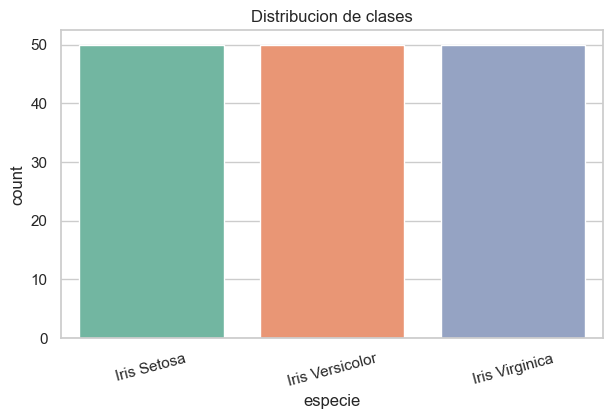

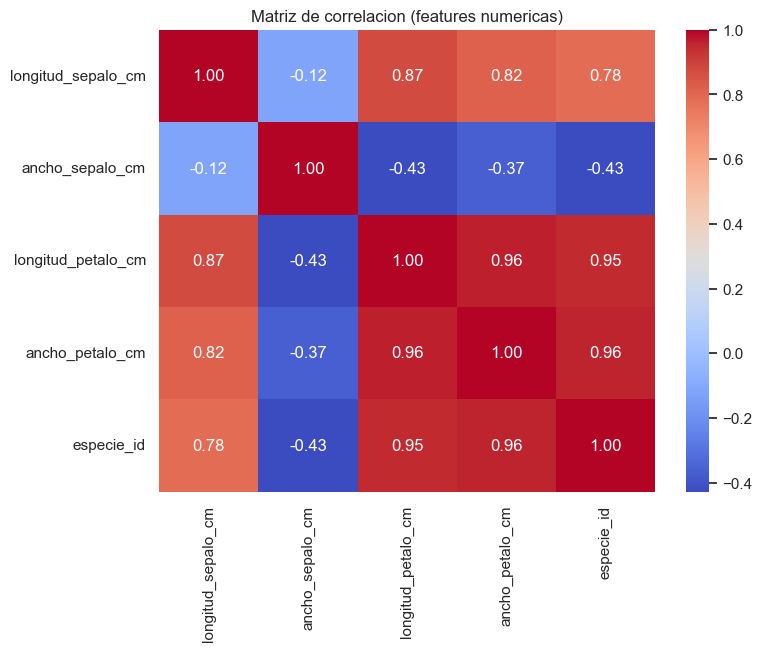

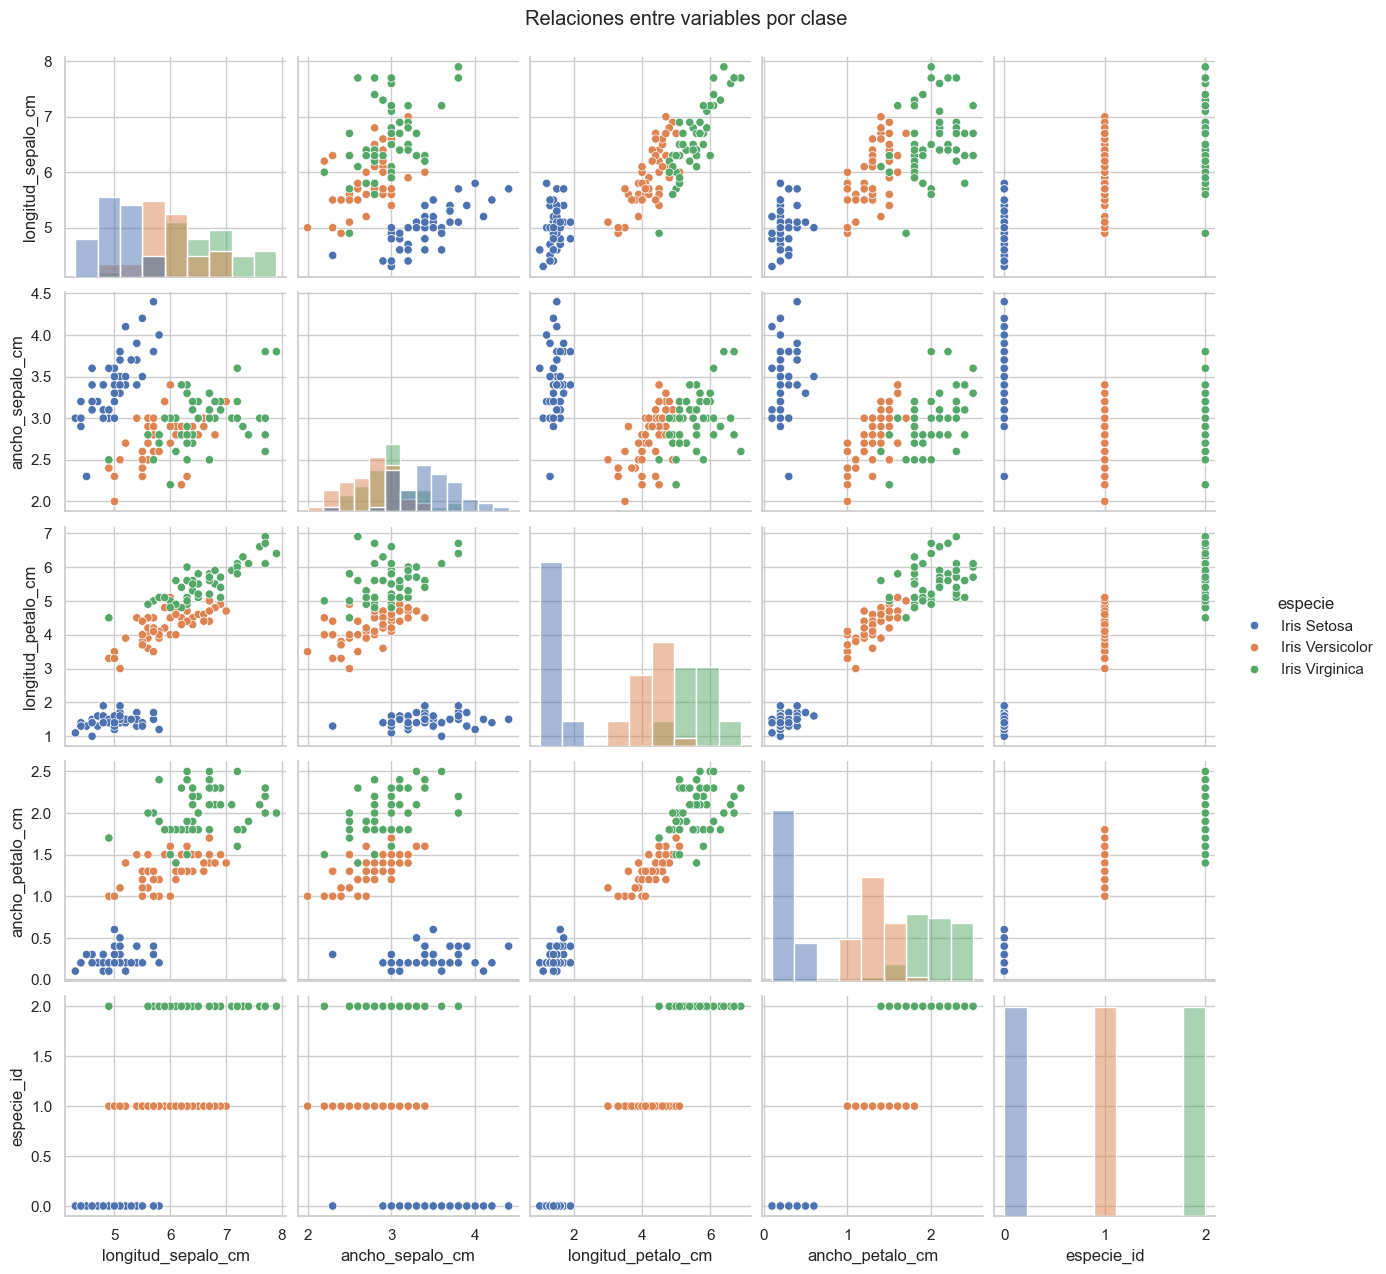

In [3]:
# Intentamos detectar automaticamente la columna objetivo
candidate_targets = ['species', 'Species', 'class', 'Class', 'target', 'Target']
target_col = next((c for c in candidate_targets if c in df.columns), df.columns[-1])

print(f'Columna objetivo detectada: {target_col}')
print('Distribucion de clases:')
print(df[target_col].value_counts())

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x=target_col, palette='Set2')
plt.title('Distribucion de clases')
plt.xticks(rotation=15)
plt.show()

# Seleccion de columnas numericas para correlacion
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlacion (features numericas)')
plt.show()

# Graficos basicos para visualizar separacion entre clases
sns.pairplot(df, hue=target_col, diag_kind='hist')
plt.suptitle('Relaciones entre variables por clase', y=1.02)
plt.show()

## 4. Preprocesamiento

Separamos variables de entrada (X) y etiqueta (y). Luego codificamos las etiquetas de clase a formato numerico para la red neuronal.

In [4]:
# Features: tomamos las 4 columnas numericas principales del dataset Iris
X = df[numeric_cols].copy()
y_raw = df[target_col].copy()

# Codificacion de etiquetas a enteros
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)

# One-hot encoding para usar categorical_crossentropy
num_classes = len(np.unique(y_encoded))
y_categorical = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)

print('Forma de X:', X.shape)
print('Forma de y (one-hot):', y_categorical.shape)
print('Clases detectadas:', list(label_encoder.classes_))

Forma de X: (150, 5)
Forma de y (one-hot): (150, 3)
Clases detectadas: ['Iris Setosa', 'Iris Versicolor', 'Iris Virginica']


## 5. Normalizacion de datos

Usamos StandardScaler para llevar cada feature a media 0 y desviacion estandar 1.

Esto mejora la estabilidad del entrenamiento, evita que una variable domine por escala y suele acelerar la convergencia con Adam y ReLU.

## 6. Division de datos (70/15/15)

In [5]:
# Primera division: 70% train, 30% temporal
X_train, X_temp, y_train, y_temp, y_train_int, y_temp_int = train_test_split(
    X, y_categorical, y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

# Segunda division del bloque temporal: 15% validacion y 15% prueba
X_val, X_test, y_val, y_test, y_val_int, y_test_int = train_test_split(
    X_temp, y_temp, y_temp_int,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_int
)

# Ajustar scaler SOLO con train para evitar fuga de informacion
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print('Train:', X_train_scaled.shape, y_train.shape)
print('Val  :', X_val_scaled.shape, y_val.shape)
print('Test :', X_test_scaled.shape, y_test.shape)

Train: (105, 5) (105, 3)
Val  : (22, 5) (22, 3)
Test : (23, 5) (23, 3)


## 7. Arquitectura de la red neuronal

Configuracion:
- Entrada: 4 neuronas
- Capas ocultas densas con ReLU
- Dropout para regularizacion
- Capa de salida Softmax para clasificacion multiclase
- Optimizador Adam y perdida categorical_crossentropy

In [6]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(1e-3)),
    Dropout(0.25),
    Dense(16, activation='relu', kernel_regularizer=l2(1e-3)),
    Dropout(0.20),
    Dense(8, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\User-PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 883 (3.45 KB)

 Trainable params: 883 (3.45 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Prevencion de sobreajuste

Tecnicas aplicadas:
- Dropout: desactiva neuronas aleatoriamente durante entrenamiento, reduciendo dependencia excesiva entre nodos.
- EarlyStopping: detiene el entrenamiento cuando la validacion deja de mejorar, evitando memorizar ruido.
- Validacion explicita: permite vigilar diferencia entre train y validation para controlar generalizacion.

In [7]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

## 9. Entrenamiento del modelo

In [8]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=250,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

print('Entrenamiento finalizado.')

Epoch 1/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.3714 - loss: 1.0809 - val_accuracy: 0.5000 - val_loss: 1.0485
Epoch 2/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5143 - loss: 1.0364 - val_accuracy: 0.5909 - val_loss: 1.0293
Epoch 3/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4667 - loss: 1.0403 - val_accuracy: 0.6364 - val_loss: 1.0048
Epoch 4/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5333 - loss: 1.0204 - val_accuracy: 0.6364 - val_loss: 0.9803
Epoch 5/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5905 - loss: 0.9779 - val_accuracy: 0.6364 - val_loss: 0.9544
Epoch 6/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6667 - loss: 0.9299 - val_accuracy: 0.6818 - val_loss: 0.9297
Epoch 7/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6952 - loss: 0.9138 - val_accuracy: 0.7273 - val_loss: 0.9033
Epoch 8/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7714 - loss: 0.8814 - val_accuracy: 0.7727 - val_loss

## 10. Evaluacion del modelo

Se reportan accuracy, precision, recall y classification report sobre el conjunto de prueba para medir generalizacion real.

In [9]:
# Predicciones en test
y_pred_proba = model.predict(X_test_scaled)
y_pred_int = np.argmax(y_pred_proba, axis=1)
y_true_int = np.argmax(y_test, axis=1)

acc = accuracy_score(y_true_int, y_pred_int)
prec = precision_score(y_true_int, y_pred_int, average='weighted', zero_division=0)
rec = recall_score(y_true_int, y_pred_int, average='weighted', zero_division=0)

print(f'Accuracy (test):  {acc:.4f}')
print(f'Precision (test): {prec:.4f}')
print(f'Recall (test):    {rec:.4f}')
print('\nClassification Report:')
print(classification_report(y_true_int, y_pred_int, target_names=label_encoder.classes_))

print('Nota: si train y validation se acercan de forma razonable sin fijarse en 1.0 exacto, el modelo suele generalizar mejor.')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
Accuracy (test):  1.0000
Precision (test): 1.0000
Recall (test):    1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris Setosa       1.00      1.00      1.00         7
Iris Versicolor       1.00      1.00      1.00         8
 Iris Virginica       1.00      1.00      1.00         8

       accuracy                           1.00        23
      macro avg       1.00      1.00      1.00        23
   weighted avg       1.00      1.00      1.00        23

Nota: si train y validation se acercan de forma razonable sin fijarse en 1.0 exacto, el modelo suele generalizar mejor.


## 11. Graficas

Visualizamos curvas de entrenamiento y matriz de confusion para interpretar el comportamiento del modelo.

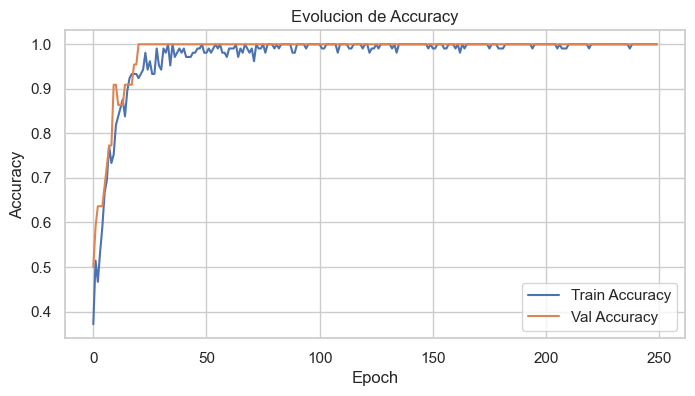

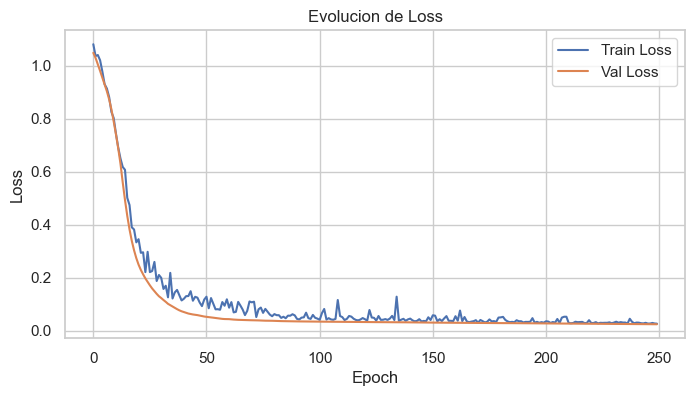

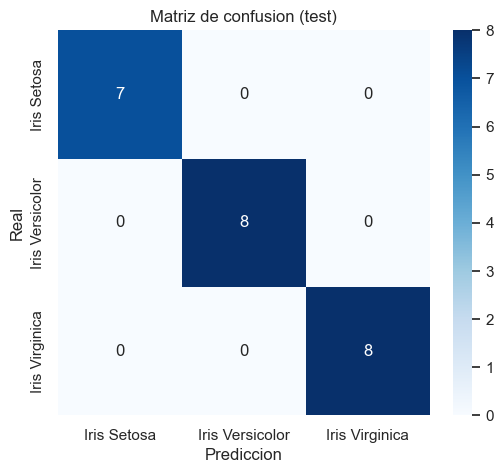

In [10]:
# Accuracy
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Evolucion de Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Evolucion de Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Matriz de confusion
cm = confusion_matrix(y_true_int, y_pred_int)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Matriz de confusion (test)')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()

## 12. Prediccion con datos personalizados

Se ingresan 4 valores en el mismo orden de las features, se aplica la misma normalizacion y se muestra la clase final predicha.

In [11]:
def predecir_flor(personalizado_4_features):
    """Recibe una lista/array con 4 valores y retorna la clase predicha."""
    datos = np.array(personalizado_4_features, dtype=float).reshape(1, -1)
    if datos.shape[1] != 4:
        raise ValueError('Debes ingresar exactamente 4 valores.')

    datos_scaled = scaler.transform(datos)
    pred_proba = model.predict(datos_scaled, verbose=0)
    pred_idx = int(np.argmax(pred_proba, axis=1)[0])
    pred_clase = label_encoder.inverse_transform([pred_idx])[0]

    return pred_clase, pred_proba[0]

# Ejemplo de uso con datos personalizados
# Orden esperado: [sepal_length, sepal_width, petal_length, petal_width]
muestra = [5.1, 3.5, 1.4, 0.2]
clase, probabilidades = predecir_flor(muestra)

print('Datos ingresados:', muestra)
print('Probabilidades por clase:')
for nombre, proba in zip(label_encoder.classes_, probabilidades):
    print(f'  {nombre}: {proba:.4f}')
print('Prediccion final:', clase)

# Si deseas entrada manual, puedes descomentar:
# entrada = [float(input('Ingresa valor 1: ')), float(input('Ingresa valor 2: ')),
#           float(input('Ingresa valor 3: ')), float(input('Ingresa valor 4: '))]
# clase_manual, _ = predecir_flor(entrada)
# print('Prediccion final:', clase_manual)

c:\Users\User-PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: X has 4 features, but StandardScaler is expecting 5 features as input.